## Load libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import unyt

import os
from glob import glob
from pathlib import Path

# For Swift Emulator training and validation
import swiftemulator as se
from swiftemulator.design import latin
from swiftemulator.io.swift import load_parameter_files
from swiftemulator.emulators import gaussian_process, gaussian_process_bins, gaussian_process_mcmc, gaussian_process_one_dim, linear_model, multi_gaussian_process
from swiftemulator.mean_models.polynomial import PolynomialMeanModel
from swiftemulator.sensitivity import basic, cross_check, cross_check_bins
from swiftemulator.mocking import mock_sweep


# For reading in simulation observables as Velociraptor HDF5 files
from velociraptor.observations import load_observation, load_observations


# For saving emulator for later use
import dill

## Load simulated data (galaxy functions, scaling relations, ...)

In [2]:
#snap_prefix = 'simba_s25n256'  # eg. 'simba_s12.5n128'
snap_prefix = 'snapshot'

# Main directory where calibration runs have been performed - Adjust this for whatever I am using
#root_dir = '/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x'
root_dir =  '/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs'
# entropy_venv_4stlock@nia-login03:/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0000$ 

# Subdirectory that holds actual calibration runs
# cali_dir = 'calibrations'
cali_dir = 'BAL_variations'

# Name of simulation observable, eg. 'gsmf'
obs_name = '151_entropy_profile_common'
# obs_name = 'gsmf_log_data_0015'
# obs_name = 'gsmfv2_log_data_0015'
# obs_name = 'gsmf_log_data_0015'
# obs_name = 'gsmf_log_data_min10gal_0015'
# obs_name = 'bhmsm_binned_log_median_0015'

# obs_name = 'bhmsm_binned_log_median_min10gal_0015'
# obs_name = 'bhmsm_kh13_log_fit_0015'
# obs_name = 'bhmsm_log_data_0015'
# obs_name = 'csfh_log_data'  # eg. 'gsmf'
# obs_name = 'csfh_binned_log_median'
# obs_name = 'quenched_fraction_0015'
# obs_name = 'massive_quenched_fraction_0015'
# obs_name = 'quenched_fraction_v2_0015'
# obs_name = 'lowMstar11_quenched_fraction_v2_0015'
# obs_name = 'ssfr_hist_bin_0_0015'

In [3]:
sim_paths = [Path(x) for x in glob(os.path.join(root_dir, cali_dir, 'run*', snap_prefix+'_'+obs_name+'.hdf5')) 
             if os.path.exists(x) and 'run06' not in x]

cali_dirs = [Path(x) for x in glob(os.path.join(root_dir, cali_dir, 'run*')) 
             if os.path.exists(os.path.join(x, snap_prefix+'_'+obs_name+'.hdf5')) and 'run06' not in x]

cali_dirnames = {dirname.stem: dirname for dirname in cali_dirs}
cali_list = [dirname.stem for dirname in cali_dirs]
print(sim_paths)
print(cali_list)
print(len(cali_list))

[PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run04/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run08/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run10/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run02/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run01/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run05/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run09/snapshot_151_entropy_profile

In [4]:
print(sim_paths)
print(cali_dirs)

[PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run04/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run08/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run10/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run02/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run01/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run05/snapshot_151_entropy_profile_common.hdf5'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run09/snapshot_151_entropy_profile

In [5]:
sim_dict = {}
thin = 1

for cali, sim_path in zip(cali_list, sim_paths):
    print(cali)
    sim_file = sim_path
    sim_data = load_observations(sim_file)[0]

    try:
        sim_data = load_observations(sim_file)[0]
    except:
        print('Failed')
        continue

    # Load simulation observable data
    
    x_ = sim_data.x.value
    y_ = sim_data.y.value
    y_err_ = sim_data.y_scatter.value

    
    # Sanitize data of -inf, +inf, NaN values
    # Data for different simulations may have different array lengths
    isfinite = np.isfinite(x_)
    isfinite_err = np.resize(isfinite, np.shape(y_err_))
    x_ = x_[isfinite]
    y_ = y_[isfinite]
    y_err_copy = y_err_[isfinite_err]
    if (y_err_copy.ndim != y_err_.ndim):
        y_err_ = y_err_copy.reshape(y_err_.ndim, -1)
    else:
        y_err_ = y_err_copy
    

    isfinite = np.isfinite(y_)
    isfinite_err = np.resize(isfinite, np.shape(y_err_))
    x_ = x_[isfinite]
    y_ = y_[isfinite]
    y_err_copy = y_err_[isfinite_err]
    if (y_err_copy.ndim != y_err_.ndim):
        y_err_ = y_err_copy.reshape(y_err_.ndim, -1)
    else:
        y_err_ = y_err_copy
    
    
    # Get 1D errors
    y_err_arr = np.array(y_err_)
    if (y_err_arr.ndim!=1):
        mean_y_err_ = np.nanmean(y_err_arr, axis=0)
        max_y_err_ = np.nanmax(y_err_arr, axis=0)
    else:
        mean_y_err_ = y_err_arr
        max_y_err_ = y_err_arr
    
    
    sim_dict[cali] = {'x':x_[::thin], 'y':y_[::thin],
                      'y_err':y_err_, 'mean_y_err':mean_y_err_[::thin], 'max_y_err':max_y_err_[::thin], 
                      'sim_data':sim_data}

run04
run08
run10
run02
run01
run05
run09
run03
run07


In [6]:
sim_data = load_observations(sim_file)[0]
sim_info = {
    'X_LABEL':sim_data.x_description,
    'Y_LABEL':sim_data.y_description,
    'name':sim_data.name,
    'x_units':sim_data.x_units,
    'y_units':sim_data.y_units,
    'comment':sim_data.comment,
    'z':sim_data.redshift,
    'z_lo':sim_data.redshift_lower,
    'z_hi':sim_data.redshift_upper,
    'plot_as':sim_data.plot_as,
}

x:  [-1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103 -0.59729758
 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966  0.37490311
  0.53693656  0.69897   ]
y:  [-0.26843359  0.02807941  0.3270925   0.4989047   0.52839897  0.56018896
  0.64215823  0.65192644  0.58818297  0.51363102  0.47495209  0.63268809
  0.7946471   0.85420424]
yerr:  [0.19587473 0.15049124 0.13735162 0.13400818 0.1102083  0.1957226
 0.38609376 0.34281145 0.16872976 0.12583011 0.18573132 0.22093558
 0.24624319 0.27923676]


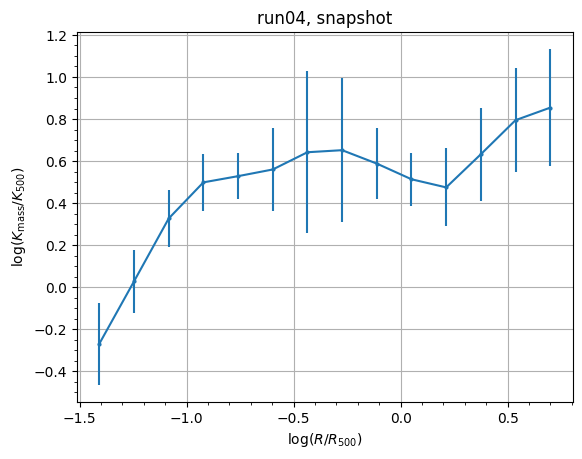

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.36242622 -0.11776195  0.22349921  0.38854633  0.43601878  0.42224822
  0.44122125  0.45733841  0.4677885   0.48933293  0.52221028  0.53941778
  0.61748467  0.81493621  0.95742219]
yerr:  [0.13411939 0.14312657 0.10110253 0.07740599 0.05524283 0.05685236
 0.05782768 0.08167301 0.13959994 0.14678882 0.12100261 0.16506707
 0.20863036 0.2565721  0.2737879 ]


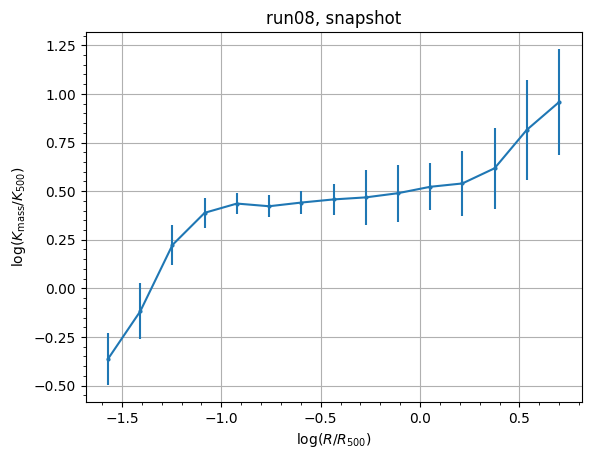

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.49301789 -0.10223556  0.14850272  0.33012608  0.34100667  0.3687863
  0.38873515  0.39273783  0.36024612  0.38258807  0.42644545  0.48481356
  0.62828732  0.78065244  0.97329607]
yerr:  [0.1075597  0.11526283 0.09332077 0.04665549 0.07749743 0.17312226
 0.24478469 0.32935637 0.16449353 0.10335928 0.14274272 0.1983553
 0.25526901 0.22011593 0.32052864]


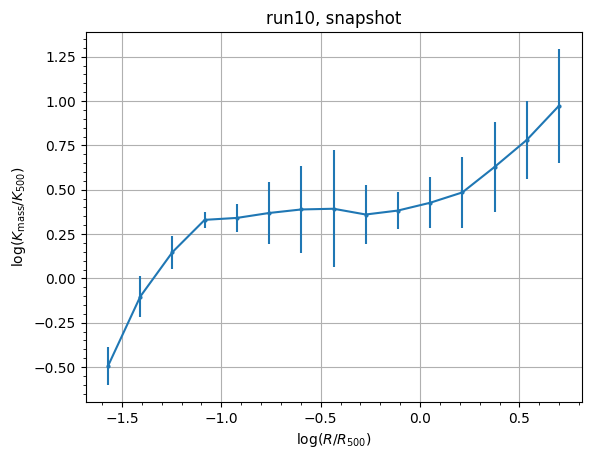

x:  [-2.05559862 -1.89356517 -1.73153172 -1.56949827 -1.40746483 -1.24543138
 -1.08339793 -0.92136448 -0.75933103 -0.59729758 -0.43526413 -0.27323069
 -0.11119724  0.05083621  0.21286966  0.37490311  0.53693656  0.69897   ]
y:  [-1.61226168 -1.18374258 -1.03263488 -0.84399811 -0.50977348 -0.22506488
 -0.18155902 -0.13133297 -0.08677208 -0.08908716 -0.07021591 -0.02157317
  0.08444329  0.20454173  0.36229484  0.53431062  0.78113549  0.99290303]
yerr:  [0.10467024 0.23322509 0.24027086 0.22214688 0.20838266 0.13095834
 0.08302782 0.07968607 0.08954929 0.06275171 0.05923829 0.07564308
 0.09810492 0.11985495 0.14599881 0.17413299 0.31047398 0.45843782]


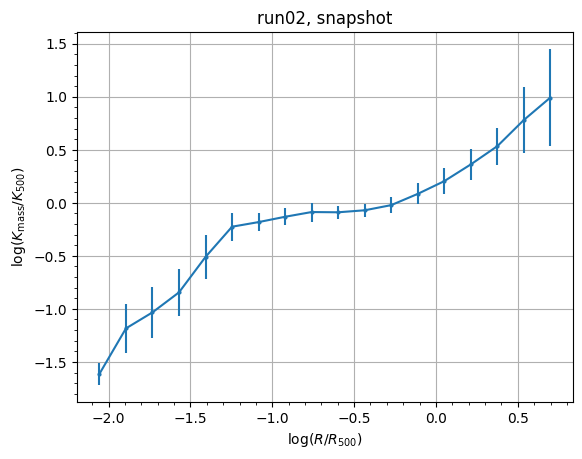

x:  [-1.89356517 -1.73153172 -1.56949827 -1.40746483 -1.24543138 -1.08339793
 -0.92136448 -0.75933103 -0.59729758 -0.43526413 -0.27323069 -0.11119724
  0.05083621  0.21286966  0.37490311  0.53693656  0.69897   ]
y:  [-1.50653029 -1.12683626 -0.79015193 -0.52091918 -0.53706245 -0.54744883
 -0.5200317  -0.45656082 -0.34148229 -0.2345999  -0.08944573  0.08208612
  0.24164824  0.4118003   0.60415872  0.80695467  0.97071359]
yerr:  [0.21760889 0.18975653 0.21940645 0.12903374 0.09219932 0.07712811
 0.06695418 0.06728096 0.07456665 0.06635779 0.08266373 0.10604496
 0.12658889 0.15458851 0.17458326 0.28972365 0.42782297]


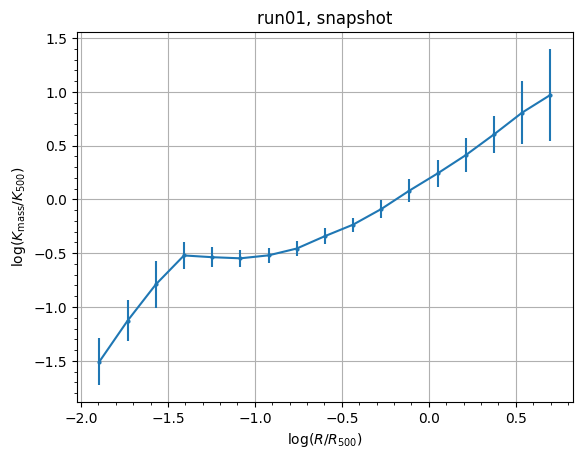

x:  [-1.73153172 -1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448
 -0.75933103 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621
  0.21286966  0.37490311  0.53693656  0.69897   ]
y:  [-0.47203999 -0.23725972 -0.16913338  0.10841171  0.13103995  0.22163588
  0.28208737  0.35465112  0.3764884   0.33158274  0.42377249  0.48495278
  0.5327485   0.61201183  0.71710002  0.82797286]
yerr:  [0.02636414 0.04879254 0.15661567 0.12279578 0.15317883 0.13692669
 0.12178507 0.14320522 0.21379822 0.19499103 0.20437256 0.19513369
 0.15320451 0.1697602  0.21040459 0.24730598]


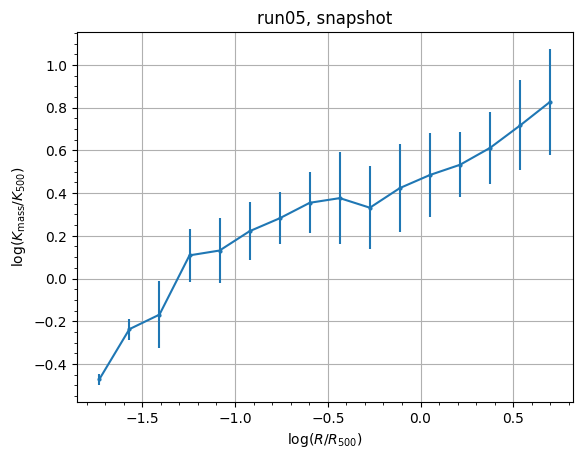

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.30973252  0.13277834  0.29222257  0.42801652  0.44025869  0.40582497
  0.4193972   0.46802066  0.49594493  0.48698264  0.44810211  0.50106366
  0.60166928  0.70623584  0.81563092]
yerr:  [0.08695622 0.04266966 0.04107131 0.0642654  0.08112021 0.12677516
 0.15507432 0.1971024  0.17990983 0.1912919  0.21407518 0.15423972
 0.15125243 0.17566044 0.24247473]


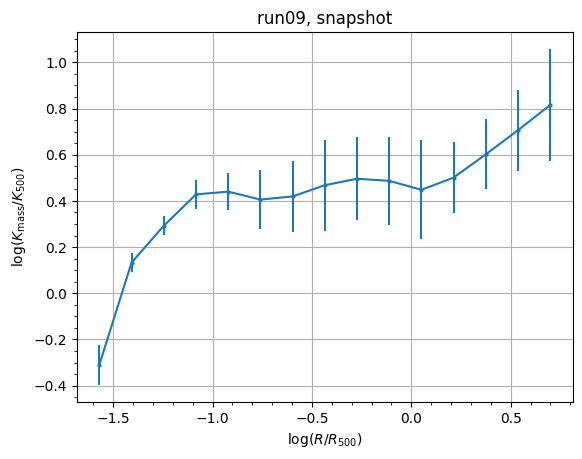

x:  [-1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103 -0.59729758
 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966  0.37490311
  0.53693656  0.69897   ]
y:  [-0.32680576 -0.01013988  0.39497704  0.45149055  0.4488876   0.45359237
  0.38900194  0.33124269  0.3554084   0.41750341  0.45196248  0.4921632
  0.61077634  0.84038764]
yerr:  [0.1715833  0.08223788 0.08668795 0.14498425 0.25653967 0.26678582
 0.17108012 0.12706362 0.1543705  0.14774319 0.14386861 0.15226253
 0.19064161 0.38430625]


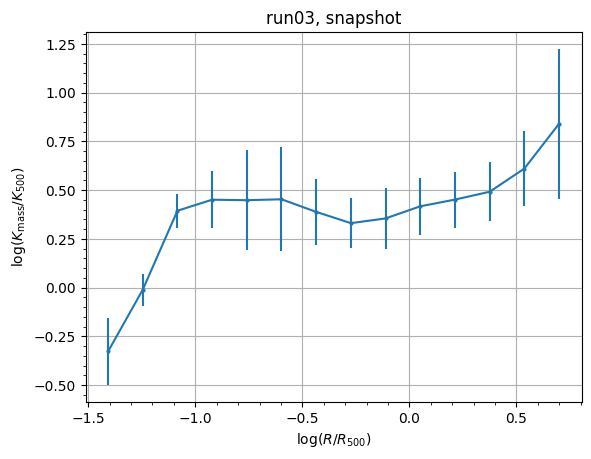

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.35831014 -0.05677018  0.23165931  0.33587537  0.3873935   0.35500763
  0.31379912  0.2649982   0.27511912  0.31691055  0.37286972  0.44472085
  0.54915679  0.72461714  0.92133021]
yerr:  [0.15356116 0.14416396 0.0801204  0.16000311 0.26663503 0.3076263
 0.1908059  0.11883051 0.13709476 0.13208902 0.12704877 0.14020516
 0.16682413 0.20027    0.21780793]


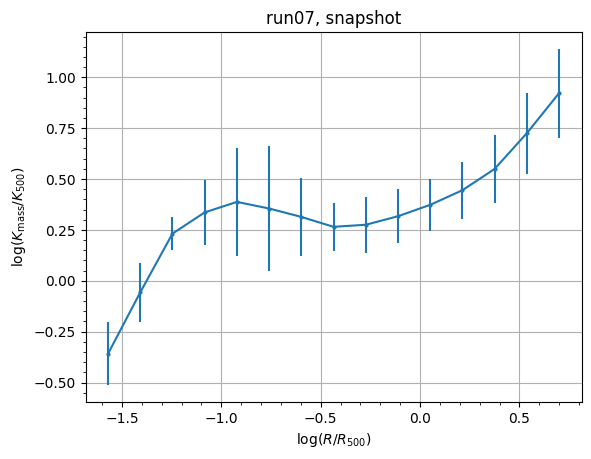

In [7]:
# Plot the observable to check it worked

thin_ = 1
# thin_ = 10 # for CSFH

for cali in sim_dict:
    print("x: ", sim_dict[cali]['x'])
    print("y: ", sim_dict[cali]['y'])
    print("yerr: ", sim_dict[cali]['max_y_err'])    
    
    plt.clf()
    plt.xlabel(sim_info['X_LABEL'])
    plt.ylabel(sim_info['Y_LABEL'])
    plt.title(r'%s, %s' % (cali, snap_prefix))
    plt.grid()
    plt.minorticks_on()
    plt.errorbar(sim_dict[cali]['x'][::thin_], sim_dict[cali]['y'][::thin_], yerr=sim_dict[cali]['max_y_err'][::thin_], 
                 fmt='o-', markersize=2)
    # plt.scatter(sim_dict[cali]['x'][::thin_], sim_dict[cali]['y'][::thin_], s=2)
    plt.show()

## Specify the model parameters and values

In [8]:
parameter_files = [Path(os.path.join(cali_dir, 'params.yml')) for cali_dir, cali in zip(cali_dirs, cali_list)]
parameter_filenames = {filename.stem: filename for filename in parameter_files}
print(parameter_filenames)
parameter_filenames = {cali: filename for cali, filename in zip(cali_list, parameter_files)}

print(parameter_files)
print(parameter_filenames)

{'params': PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run07/params.yml')}
[PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run04/params.yml'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run08/params.yml'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run10/params.yml'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run02/params.yml'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run01/params.yml'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run05/params.yml'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_finished_runs/BAL_variations/run09/params.yml'), PosixPath('/scratch/b/babul/stlock/snapshots/HyenasC/L0/halo_3224_fi

In [9]:
## Set this to what you ran the simulations with

model_specification, model_parameters = load_parameter_files(
    filenames=parameter_filenames,
    parameters=[
        "Parameters:BAL_f_accretion"
    ],
    log_parameters=[],
    parameter_printable_names=[
        r"$f_{\rm acc, BAL}$"
    ],
    #parameter_limits: Optional[List[List[float]]] = None, # for parameter limits
)

print(model_parameters)
print(model_specification)

ModelParameters(model_parameters={'run04': {'Parameters:BAL_f_accretion': 0.08}, 'run08': {'Parameters:BAL_f_accretion': 0.16}, 'run10': {'Parameters:BAL_f_accretion': 0.2}, 'run02': {'Parameters:BAL_f_accretion': 0.04}, 'run01': {'Parameters:BAL_f_accretion': 0.02}, 'run05': {'Parameters:BAL_f_accretion': 0.1}, 'run09': {'Parameters:BAL_f_accretion': 0.18}, 'run03': {'Parameters:BAL_f_accretion': 0.06}, 'run07': {'Parameters:BAL_f_accretion': 0.14}})
ModelSpecification(number_of_parameters=1, parameter_names=['Parameters:BAL_f_accretion'], parameter_limits=[[0.02, 0.2]], parameter_printable_names=['$f_{\\rm acc, BAL}$'])


In [10]:
# Im double binning here, making for choppy values!


modelvalues = {}

## Choose a min and max x value to limit the emulator to when training

# these are mass bins (make range more specific)

# Entropy Profiles
min_x_for_emulator = -1.7
max_x_for_emulator = 1.1


# GSMF
# min_x_for_emulator = 6
# min_x_for_emulator = 8.5  # Seems to be resolution limit
# min_x_for_emulator = 9
# min_x_for_emulator = 10
# max_x_for_emulator = 11
# max_x_for_emulator = 11.2
# max_x_for_emulator = 11.6
# max_x_for_emulator = 15

# Mbh-M*
# min_x_for_emulator = 6
# min_x_for_emulator = 8.2
# min_x_for_emulator = 8.5
# min_x_for_emulator = 8.75
# min_x_for_emulator = 9
# min_x_for_emulator = 9.5
# min_x_for_emulator = 10
# max_x_for_emulator = 11
# max_x_for_emulator = 11.2
# max_x_for_emulator = 11.7
# max_x_for_emulator = 12
# max_x_for_emulator = 15

# Quenched Fraction
# min_x_for_emulator = 0
# max_x_for_emulator = 100

# sSFR Histogram
# min_x_for_emulator = -2.7
# max_x_for_emulator = 0
# max_x_for_emulator = 0.5

# CSFH
# min_x_for_emulator = -1
# max_x_for_emulator = 5

# If too many data points, will take very long to train emulator and use emulator to predict values
thin_ = 1
# thin_ = 10 # for CSHF

# rel_err = 0.02 # for Mbh-M*
rel_err = 0.05 # for CSFH

for cali in model_parameters.model_parameters:
    independent = sim_dict[cali]['x'][::thin_]
    dependent = sim_dict[cali]['y'][::thin_]
    
    # Must choose whether to specify own errorbars
    # or use maximum or mean errorbars (as swift emulator can only handle single value for errorbars)
#     dependent_error = np.abs(rel_err * dependent)
#    dependent_error = sim_dict[cali]['max_y_err'][::thin_]
    dependent_error = np.array([0]*len(dependent))

    range_condition = np.logical_and(independent>=min_x_for_emulator, independent<=max_x_for_emulator)
    
    modelvalues[cali] = {"independent": independent[range_condition],
                         "dependent": dependent[range_condition],
                         "dependent_error": dependent_error[range_condition]}

model_values = se.ModelValues(model_values=modelvalues)

In [11]:
## To check if there are any x bin values appearing only once
    # emulator needs more than one sample, cause it needs to compare
## This can make errors pop up when training the emulator, doing the parameter sensitivity analysis
## and performing the cross-check validation

comb_ = np.array([])
for key, val in model_values.model_values.items():
#     print(np.all(np.isfinite(val['independent'])))
#     print(np.all(np.isfinite(val['dependent'])))
#     print(np.all(np.isfinite(val['dependent_error'])))
#     print(max(val['independent']))
    comb_ = np.concatenate((comb_, val['independent']))
#     comb_ = np.append(comb_, val['independent'])
#     comb_ = np.append(comb_, max(val['independent']))
    
# Find unique values and their counts
unique_values, counts = np.unique(comb_, return_counts=True)
print("Unique x values:", unique_values)
print("Number of times:", counts)

# Find values that appear only once
values_appearing_once = unique_values[counts == 1]

# Print the values that appear only once
print("x values appearing only once:", values_appearing_once)

Unique x values: [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
Number of times: [7 9 9 9 9 9 9 9 9 9 9 9 9 9 9]
x values appearing only once: []


## Model Parameter Features

In [12]:
print(model_parameters)
print(model_specification)

ModelParameters(model_parameters={'run04': {'Parameters:BAL_f_accretion': 0.08}, 'run08': {'Parameters:BAL_f_accretion': 0.16}, 'run10': {'Parameters:BAL_f_accretion': 0.2}, 'run02': {'Parameters:BAL_f_accretion': 0.04}, 'run01': {'Parameters:BAL_f_accretion': 0.02}, 'run05': {'Parameters:BAL_f_accretion': 0.1}, 'run09': {'Parameters:BAL_f_accretion': 0.18}, 'run03': {'Parameters:BAL_f_accretion': 0.06}, 'run07': {'Parameters:BAL_f_accretion': 0.14}})
ModelSpecification(number_of_parameters=1, parameter_names=['Parameters:BAL_f_accretion'], parameter_limits=[[0.02, 0.2]], parameter_printable_names=['$f_{\\rm acc, BAL}$'])


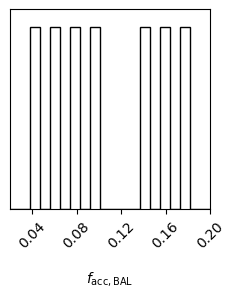

In [13]:
model_parameters.plot_model(model_specification)

# x axis is wind speed, y axis is as labeled

## Train emulator

In [14]:
for cali in model_parameters.model_parameters:
    independent = sim_dict[cali]['x'][::thin_]
    dependent = sim_dict[cali]['y'][::thin_]
    dependent_error = sim_dict[cali]['max_y_err'][::thin_]

    range_condition = np.logical_and(independent >= min_x_for_emulator,
                                     independent <= max_x_for_emulator)

    # Select values in range
    independent = independent[range_condition]
    dependent = dependent[range_condition]
    dependent_error = dependent_error[range_condition]

    # Remove NaNs and Infs
    mask = np.isfinite(independent) & np.isfinite(dependent) & np.isfinite(dependent_error)
    independent = independent[mask]
    dependent = dependent[mask]
    dependent_error = dependent_error[mask]

    # Save clean data
    modelvalues[cali] = {
        "independent": independent,
        "dependent": dependent,
        "dependent_error": dependent_error,
    }

In [15]:
emulator = gaussian_process.GaussianProcessEmulator()  # Default, MAKE IT
# emulator = gaussian_process_mcmc.GaussianProcessEmulatorMCMC(mcmc_steps=1000, burn_in_steps=1, walkers=40, use_hyperparameter_error=False)  # With MCMC
# emulator = gaussian_process_bins.GaussianProcessEmulatorBins()  # Gaussian Process Emulator using an emulator for each bins
# emulator = gaussian_process_one_dim.GaussianProcessEmulator1D()  # Gaussian Process Emulator for emulating single values
# emulator = linear_model.LinearModelEmulator(lasso_model_alpha=0)  # Linear Model Emulator
# emulator = multi_gaussian_process.MultipleGaussianProcessEmulator()  # A gaussian process emulator that uses _multiple_ internal emulators to better predict functions that contain a ‘break’.
# polynomial_model = PolynomialMeanModel(degree=4)  # Polynomial mean model
# emulator = gaussian_process.GaussianProcessEmulator(mean_model=polynomial_model)  # Mean model

emulator.fit_model(model_specification=model_specification, #TRAIN IT
                            model_parameters=model_parameters,
                            model_values=model_values)
emulator.model_specification.sim_info = sim_info # LINK IT

#ALL TRAINING IS DONE HERE, ALL AFTER IS TO CHECK HOW WELL IT WORKED

## Make predictions and compare

x:  [-1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103 -0.59729758
 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966  0.37490311
  0.53693656  0.69897   ]
y:  [-0.06207062  0.15110029  0.32828851  0.44884218  0.50797243  0.51666518
  0.49685335  0.47391473  0.46917274  0.49458546  0.5506888   0.62773008
  0.70917078  0.77640042]
yerr:  [0.00309769 0.00238733 0.00222977 0.00226394 0.00257802 0.00308301
 0.00348936 0.00356835 0.00337977 0.00322553 0.00338536 0.00415833
 0.00664371 0.01370555]
Slope:  [1.3155981792726257, 1.0935286228337215, 0.7440048208031916, 0.3649262265271463, 0.05364787004145865, -0.12227000135978838, -0.14156717131308397, -0.029265486579230827, 0.1568362066402626, 0.3462454781097565, 0.47546522728461543, 0.5026166444285844, 0.41491208180756767]


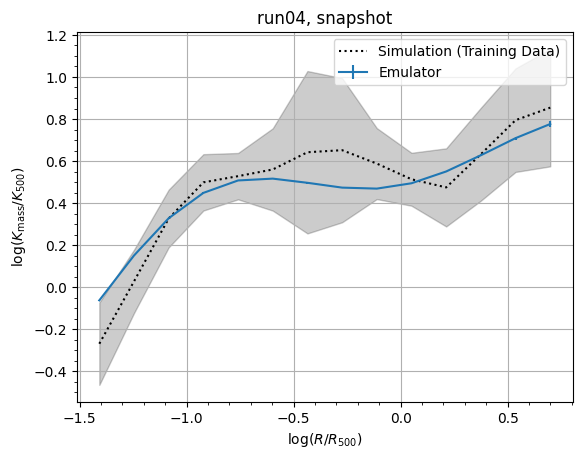

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.20411795  0.05615572  0.26054021  0.3899911   0.44689212  0.45067143
  0.42871408  0.40695564  0.40373316  0.42801937  0.48076388  0.55710197
  0.6479065   0.74064323  0.82050504]
yerr:  [0.00418754 0.00176598 0.00116975 0.00097665 0.00086583 0.00084767
 0.00099491 0.0013472  0.00182434 0.00229131 0.00271569 0.003187
 0.00396798 0.00606242 0.01212004]
Slope:  [1.6062959389799754, 1.261372180706746, 0.7989146564006657, 0.3511683208807709, 0.02332429319799683, -0.1355112685784665, -0.13428358879527846, -0.019887782811106133, 0.14988397579731091, 0.3255161366606776, 0.47112549539288306, 0.5604061416856244, 0.5723307660765562, 0.49287236552928293]


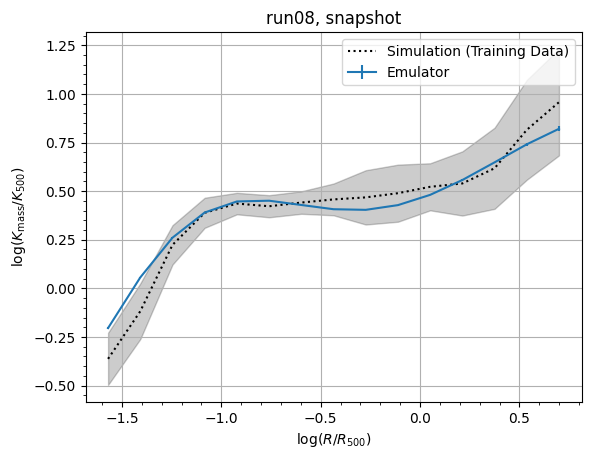

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.33893754 -0.06561971  0.15566421  0.30211517  0.37298838  0.38626677
  0.36987769  0.35164553  0.35185217  0.38019947  0.43658778  0.51379635
  0.60030802  0.68257359  0.74696348]
yerr:  [0.00543098 0.00258506 0.00152775 0.00119807 0.00171637 0.00297715
 0.00425466 0.00480091 0.00456475 0.00423589 0.00457974 0.00583697
 0.00805351 0.01230831 0.02164528]
Slope:  [1.6867987933319322, 1.365668166467521, 0.9038316406571693, 0.4373986295191685, 0.0819484766484763, -0.10114628626194436, -0.11252094687667182, 0.0012753112583643355, 0.17494721336434316, 0.3480040995913136, 0.47649776307028713, 0.5339124000986478, 0.5077073040813908, 0.39738640041135437]


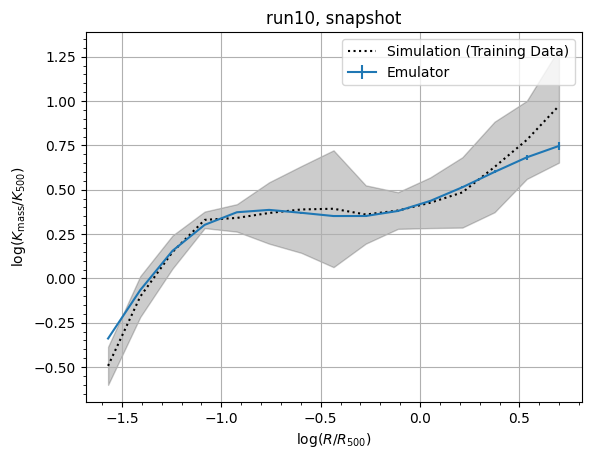

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.57819076 -0.42974972 -0.28932526 -0.17935378 -0.10970573 -0.07507193
 -0.05772881 -0.03443209  0.01533841  0.10276603  0.22668019  0.3745208
  0.52631919  0.66006478  0.75685418]
yerr:  [0.01067331 0.00438873 0.00219045 0.00152308 0.00129335 0.00116023
 0.00105264 0.00102974 0.00119895 0.00160333 0.00218827 0.00296732
 0.00449819 0.00859161 0.01864852]
Slope:  [0.9161135546035127, 0.8666387519871939, 0.6786961721817892, 0.4298374713373835, 0.21374476827121205, 0.10703415861861111, 0.1437772704739002, 0.3071618674369652, 0.5395652353725054, 0.7647443321356445, 0.9124079823419627, 0.9368336397065383, 0.8254196674602258, 0.5973420842569125]


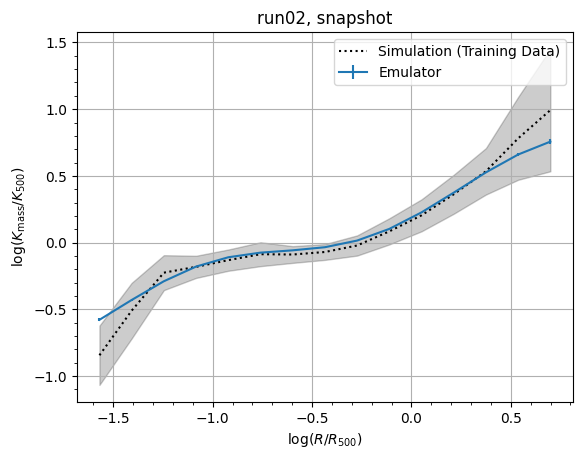

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.6756869  -0.62447846 -0.57342393 -0.52837009 -0.48657706 -0.43762874
 -0.36759484 -0.26472993 -0.12442793  0.0483537   0.23979536  0.43041969
  0.5994775   0.72915808  0.80768063]
yerr:  [0.01167576 0.00488395 0.00244026 0.00162839 0.00132533 0.00122222
 0.00123358 0.00136455 0.00170149 0.00232085 0.00325166 0.00470737
 0.00762923 0.01424319 0.02798321]
Slope:  [0.3160362420480779, 0.31508635963736004, 0.278052716736691, 0.25792840111870996, 0.3020877342224976, 0.4322188041998411, 0.6348375015358911, 0.8658829131314095, 1.0663331243626737, 1.1814946936343265, 1.1764504811662861, 1.0433513403236587, 0.8003321205011169, 0.48460702918625914]


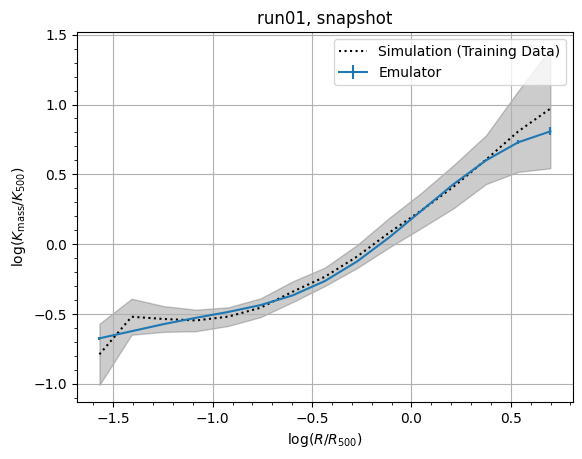

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.25894126 -0.0825693   0.08594112  0.22396349  0.318667    0.36959294
  0.38733627  0.38924178  0.39389057  0.41612071  0.46367775  0.53585359
  0.62401548  0.7137535   0.78825354]
yerr:  [0.00208219 0.00201565 0.00288692 0.00314576 0.00305667 0.00318828
 0.00366915 0.00422692 0.00453809 0.00453561 0.00444915 0.00458999
 0.0053457  0.00785239 0.01490334]
Slope:  [1.088491058566414, 1.0399730991822413, 0.8518140229009223, 0.5844689116367711, 0.31429275671920087, 0.10950412158700769, 0.011760007106659311, 0.028690316980642363, 0.13719475450935245, 0.29350133256930294, 0.445437934565474, 0.5440968674740044, 0.5538240179205656, 0.45978187936012177]


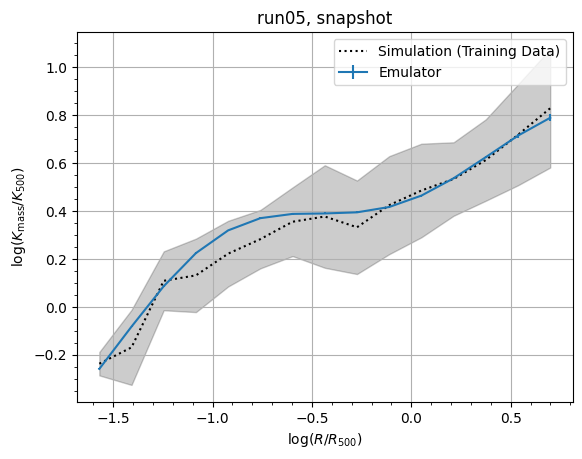

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.22891615  0.05957773  0.28678544  0.43096794  0.4940443   0.49704042
  0.47016209  0.4422395   0.43357946  0.45371285  0.50288221  0.57488693
  0.65943851  0.74363837  0.81332502]
yerr:  [0.00243628 0.00080193 0.00064995 0.00077935 0.00108984 0.00160241
 0.00218158 0.00265725 0.00296175 0.00316826 0.00340132 0.00370674
 0.00425645 0.00617328 0.01243327]
Slope:  [1.7804587940776702, 1.4022272162125171, 0.8898317092902988, 0.3892798575947393, 0.018490787974429598, -0.16588137934230285, -0.17232612730693334, -0.05344594970627433, 0.12425447968361696, 0.3034519438415892, 0.44438183986258567, 0.5218155557660265, 0.5196449511723553, 0.43007570376980625]


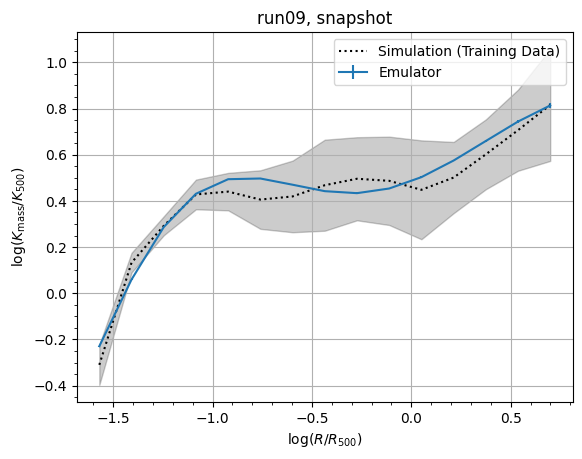

x:  [-1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103 -0.59729758
 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966  0.37490311
  0.53693656  0.69897   ]
y:  [-0.17932574  0.03130764  0.20106851  0.30985086  0.3556474   0.3537122
  0.33031773  0.31370444  0.32551976  0.37535676  0.45949622  0.56343371
  0.6668026   0.74901632]
yerr:  [0.00452745 0.00216859 0.00165442 0.00180541 0.00209463 0.00229137
 0.00234324 0.00231591 0.00233738 0.00253266 0.00299681 0.00407849
 0.00715234 0.01531764]
Slope:  [1.2999376819752928, 1.0476902691091026, 0.6713573675720615, 0.2826363343520027, -0.01194321654196709, -0.14438050620874182, -0.10253000266826172, 0.07291902871697452, 0.30757231476884794, 0.5192721653733099, 0.6414569718299675, 0.6379478362064523, 0.5073873585114513]


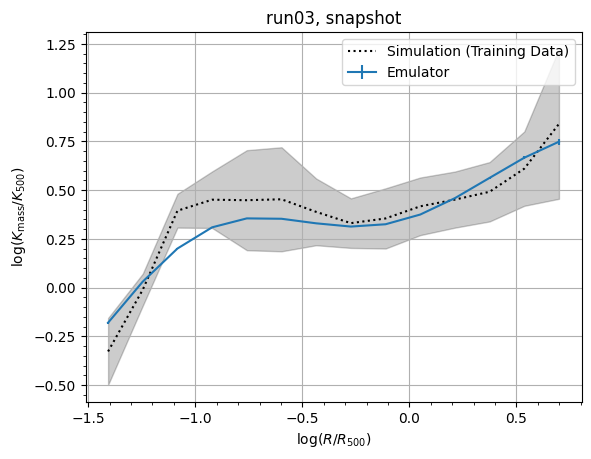

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
y:  [-0.2383708  -0.03481121  0.12868616  0.23613283  0.28829425  0.29974567
  0.29206762  0.28650489  0.29886838  0.33762246  0.40428772  0.49459093
  0.59937767  0.70542385  0.79694964]
yerr:  [0.00614438 0.00311943 0.00243539 0.0024842  0.00269546 0.0028349
 0.00283993 0.00279725 0.00280869 0.00292117 0.00318736 0.00369634
 0.00469542 0.00719242 0.01382077]
Slope:  [1.2562813015660108, 1.0090346717726035, 0.6631141699605244, 0.32191761012750014, 0.07067318882053344, -0.047385629120396684, -0.03433074262715906, 0.07630210266542832, 0.2391733342795271, 0.4114289828453829, 0.5573121826738547, 0.6466982096699021, 0.6544709324121881, 0.564857382363823]


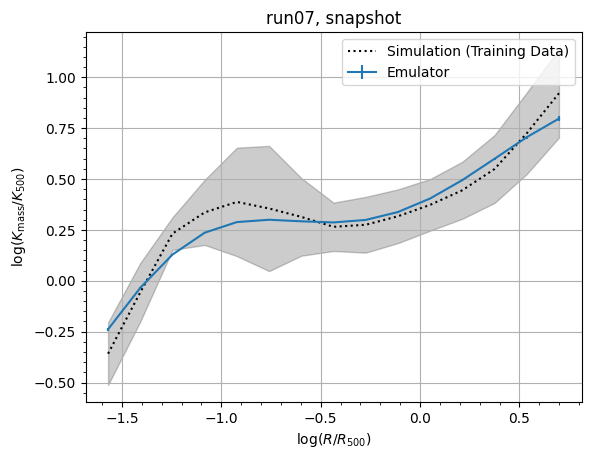

In [16]:
# Make predictions with trained emulator to compare to input

for cali in emulator.model_parameters.model_parameters:
    pred_params = emulator.model_parameters[cali]
    pred_x = emulator.model_values[cali]['independent']
    sim_y = emulator.model_values[cali]['dependent']
    sim_yerr = emulator.model_values[cali]['dependent_error']

    pred_y, pred_var = emulator.predict_values(pred_x, pred_params)
    
    print("x: ", pred_x)
    print("y: ", pred_y)
    print("yerr: ", pred_var)
    print("Slope: ", [(y2-y1)/(x2-x1) for x1, x2, y1, y2 in zip(pred_x[:-1], pred_x[1:], pred_y[:-1], pred_y[1:])])

    plt.clf()
    plt.xlabel(sim_info['X_LABEL'])
    plt.ylabel(sim_info['Y_LABEL'])
    plt.title(r'%s, %s' % (cali, snap_prefix))
    plt.grid()
    plt.minorticks_on()
    
    plt.errorbar(pred_x, sim_y, color="black", ls=":", label="Simulation (Training Data)")
#     plt.scatter(pred_x, sim_y, color="black", label="Simulation (Training Data)")
    plt.fill_between(pred_x, sim_y-sim_yerr, sim_y+sim_yerr, color="black", alpha=0.2)
    
    plt.errorbar(pred_x, pred_y, yerr=pred_var, ls='-', label='Emulator')
#     plt.scatter(pred_x, pred_y, label='Emulator')
    plt.legend()
    plt.show()

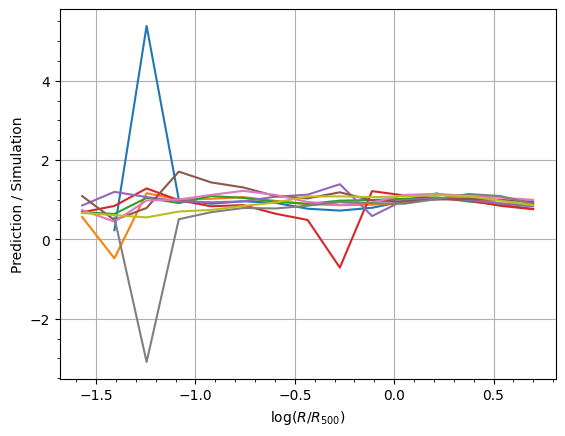

In [17]:
## See how far off each prediction is from its simulation

pred_over_sim_list = []

for cali in emulator.model_parameters.model_parameters:
    pred_params = emulator.model_parameters[cali]
    pred_x = emulator.model_values[cali]['independent']
    sim_y = emulator.model_values[cali]['dependent']

    pred_y, pred_var = emulator.predict_values(pred_x, pred_params)
    
    pred_over_sim = pred_y/sim_y
    pred_over_sim_list = np.append(pred_over_sim_list, pred_over_sim)

    plt.plot(pred_x, pred_over_sim)
#     plt.scatter(pred_x, pred_over_sim)

plt.grid()
plt.minorticks_on()
plt.xlabel(sim_info['X_LABEL'])
plt.ylabel("Prediction / Simulation")
plt.show()

## Parameter sensitivity analysis

In [18]:
# Find common x-values across all runs:
common_x_values = set(sim_dict[next(iter(sim_dict))]['x'])
for cali in sim_dict:
    common_x_values = common_x_values.intersection(set(sim_dict[cali]['x']))
common_x_values = np.array(sorted(common_x_values))

print(common_x_values)

[-1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103 -0.59729758
 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966  0.37490311
  0.53693656  0.69897   ]


In [19]:
# If get division by zero error, it is because there is one (or multiple) emulator(s) that
# have x values that no others have --> need to either re-bin so emulators all have same x
# values, or remove that one point from that emulator
emulator_sensitivities = basic.binwise_sensitivity(specification=emulator.model_specification,
                                                   parameters=emulator.model_parameters,
                                                   values=emulator.model_values)
list(emulator_sensitivities.values())

#tells which of the parameters I changes actaully impact the observable

print(emulator_sensitivities)

{'-1.407': array([1.]), '-1.245': array([1.]), '-1.083': array([1.]), '-0.9214': array([1.]), '-0.7593': array([1.]), '-0.5973': array([1.]), '-0.4353': array([1.]), '-0.2732': array([1.]), '-0.1112': array([1.]), '0.05084': array([1.]), '0.2129': array([1.]), '0.3749': array([1.]), '0.5369': array([1.]), '0.699': array([1.]), '-1.569': array([1.])}


/home/b/babul/stlock/swift/swift_venv/lib/python3.11/site-packages/SALib/analyze/rbd_fast.py:128: RuntimeWarning: invalid value encountered in scalar divide
  return D1 / V


In [ ]:
fig, ax = basic.plot_binwise_sensitivity(specification=emulator.model_specification,
                                         sensitivities=emulator_sensitivities,
                                         xlabel=sim_info['X_LABEL'],
                                         cbarlabel='Sensitivity',
                                         vmin=np.nanmin(list(emulator_sensitivities.values())),
                                         vmax=np.nanmax(list(emulator_sensitivities.values())))

# fig.set_size_inches(8, 8, forward=True)
fig.set_size_inches(8, 2, forward=True)

NameError: name 'emulator_sensitivities' is not defined

## Perform cross check (validation)

In [20]:
emulator_ccheck = cross_check.CrossCheck(hide_progress=False)
emulator_ccheck.build_emulators(model_specification=model_specification,
                        model_parameters=model_parameters,
                        model_values=model_values)


# 

100%|██████████| 9/9 [00:01<00:00,  8.79it/s]


In [21]:
data_by_cc = emulator_ccheck.build_mocked_model_values_original_independent()

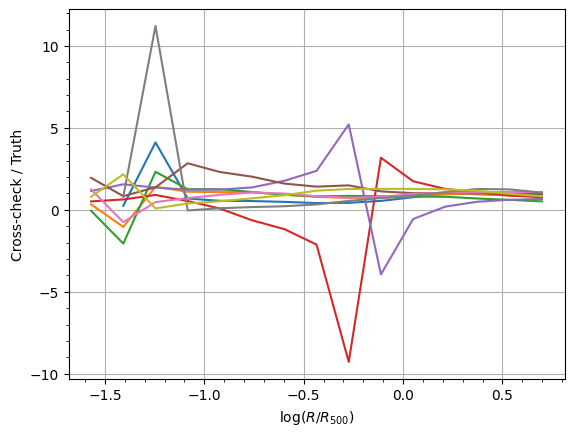

In [22]:
cc_list = []
cc_over_og_list = []

for unique_identifier in emulator_ccheck.model_values.model_values:
    cc_over_og = data_by_cc[unique_identifier]["dependent"] / \
                model_values[unique_identifier]["dependent"]

    cc_list = np.append(cc_list, data_by_cc[unique_identifier]["dependent"])
    cc_over_og_list = np.append(cc_over_og_list, cc_over_og)
    
    plt.plot(data_by_cc[unique_identifier]["independent"], cc_over_og)

plt.grid()
plt.minorticks_on()
plt.xlabel(sim_info['X_LABEL'])
plt.ylabel("Cross-check / Truth")
plt.show()

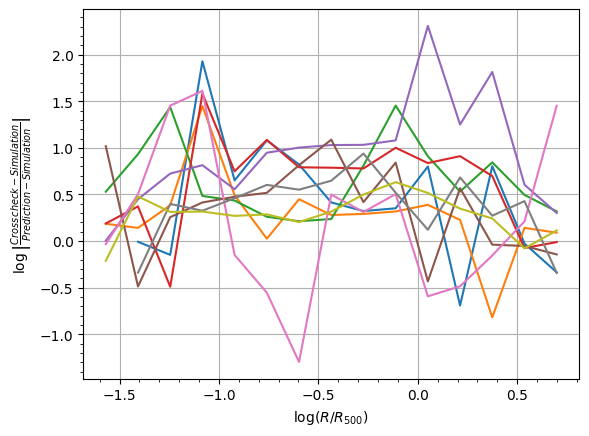

In [23]:
## Cross-check does better if y-axis value is negative (strange, but good. Machine learning is working....?)
## Original prediction does better if y-axis value is positive

pred_list = []

for unique_identifier in emulator_ccheck.model_values.model_values:
    
    pred_params = emulator.model_parameters[unique_identifier]
    pred_x = emulator.model_values[unique_identifier]['independent']
    sim_y = emulator.model_values[unique_identifier]['dependent']

    pred_y, pred_var = emulator.predict_values(pred_x, pred_params)
    
    pred_list = np.append(pred_list, pred_y)
    
    
    val_ = np.log10(np.abs((data_by_cc[unique_identifier]["dependent"] - sim_y)/(pred_y - sim_y)))
    plt.plot(data_by_cc[unique_identifier]["independent"], val_)

plt.grid()
plt.minorticks_on()
plt.xlabel(sim_info['X_LABEL'])
plt.ylabel(r'$\log{ \left| \frac{Cross \, check - Simulation}{Prediction - Simulation} \right|}$')
plt.show()

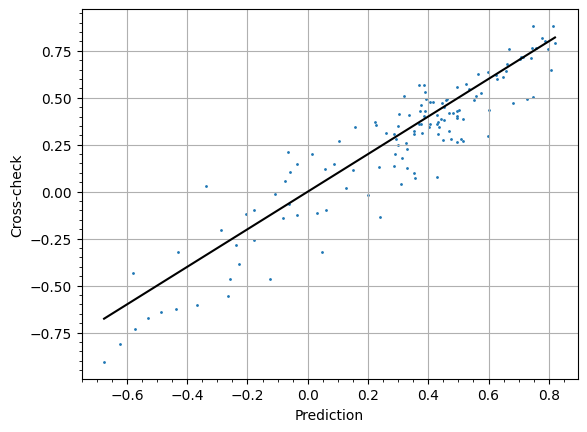

In [24]:
## Second way of comparing the cross-check for each simulation to the prediction as found by
## the fully trained emulator

plt.plot([min(pred_list), max(pred_list)], [min(pred_list), max(pred_list)], color='black')
plt.scatter(pred_list, cc_list, s=1)

plt.grid()
plt.minorticks_on()
plt.xlabel("Prediction")
plt.ylabel("Cross-check")
plt.show()

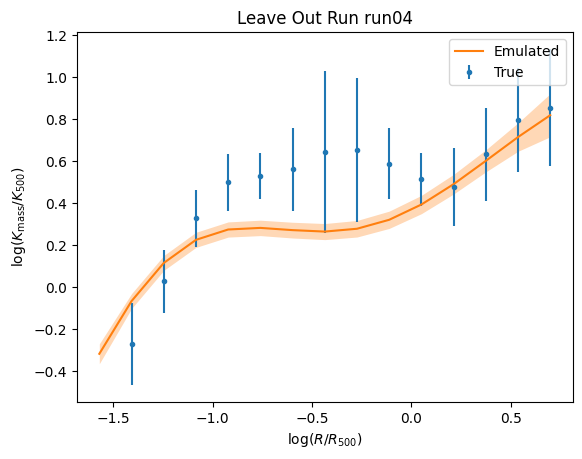

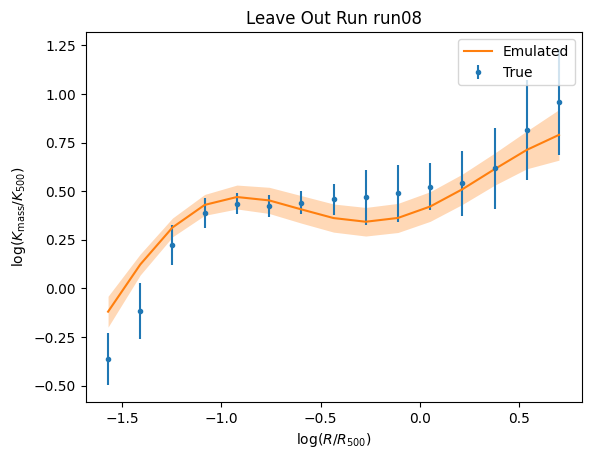

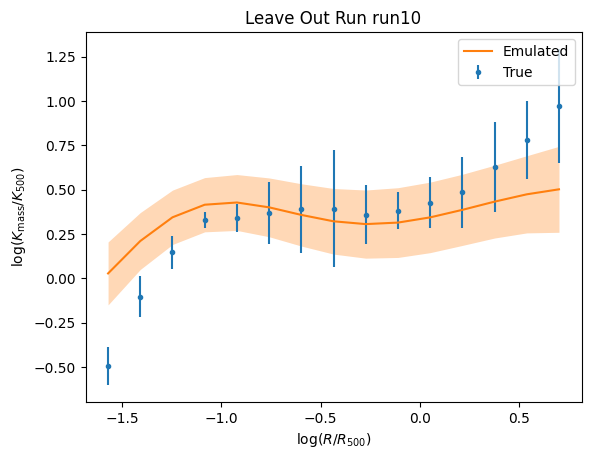

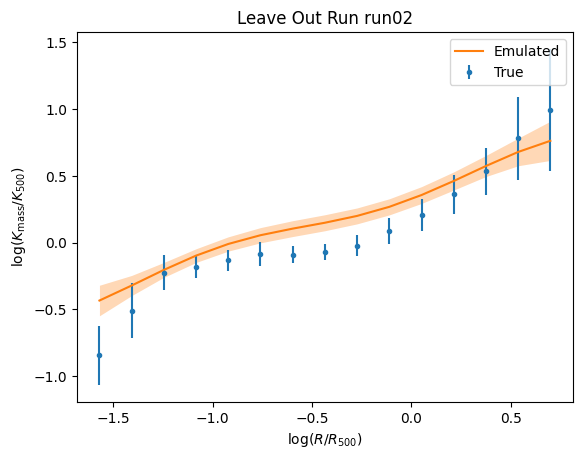

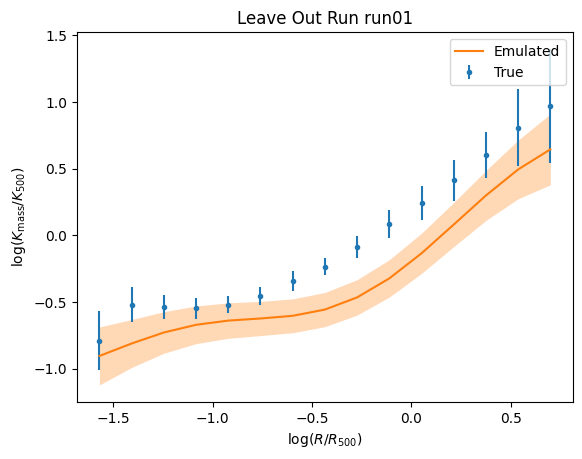

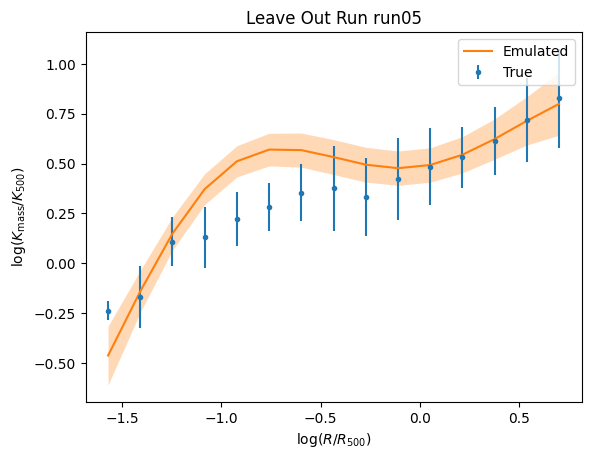

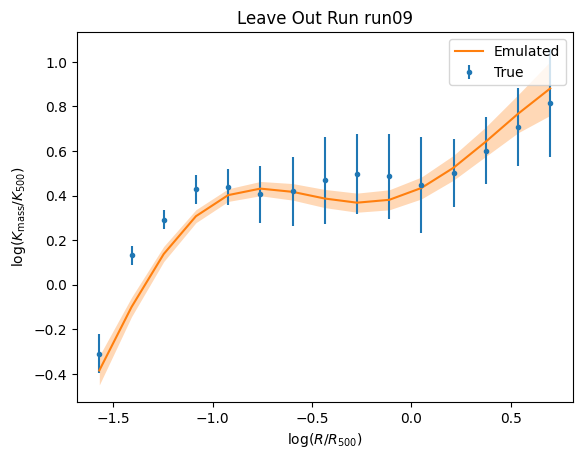

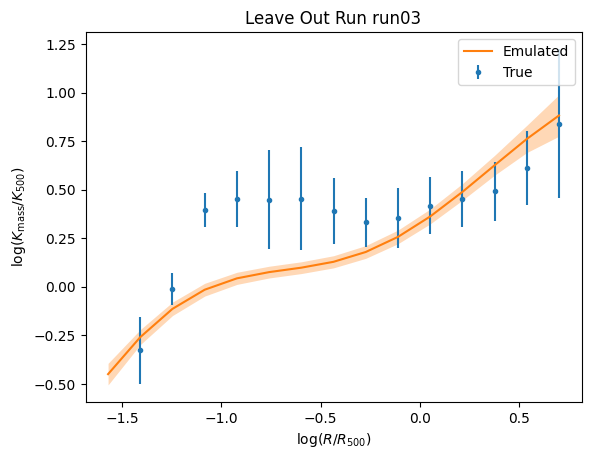

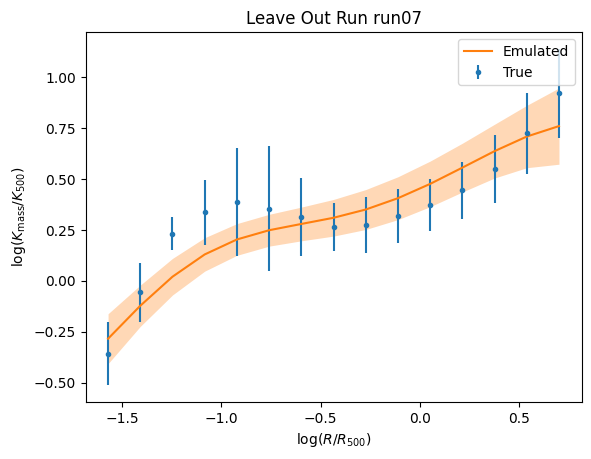

In [25]:
emulator_ccheck.plot_results(emulate_at=data_by_cc[unique_identifier]["independent"],
                         xlabel=sim_info['X_LABEL'],
                         ylabel=sim_info['Y_LABEL'])

In [26]:
total_mean_squared = emulator_ccheck.get_mean_squared()[0]
print("Total mean squared of entire set of left-out simulations: %s" % total_mean_squared)

Total mean squared of entire set of left-out simulations: 0.03681739455361698


In [27]:
## As in FLAMINGO paper (Kugel+22), error on emulator approximated as standard deviation of
## cross-check values divided by original simulation values

# sigma_ccheck = np.nanstd(cc_over_og_list)#, ddof=0)
# sigma_ccheck = total_mean_squared
sigma_ccheck = 0.1 #set to 10 percent error, easiest lol
print('sigma_ccheck =', sigma_ccheck)
emulator.model_specification.sigma_ccheck = sigma_ccheck

sigma_ccheck = 0.1


In [28]:
def emulator_model(x, pred_params, emulator):
    pred_y, pred_var = emulator.predict_values(x, pred_params)
    
    pred_std = np.sqrt(pred_var)
    pred_ccheck_std = np.abs(emulator.model_specification.sigma_ccheck * pred_y)
    pred_total = np.sqrt(pred_std**2 + pred_ccheck_std**2)
    
    return pred_y, pred_ccheck_std

x:  [-1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103 -0.59729758
 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966  0.37490311
  0.53693656  0.69897   ]
pred_y:  [-0.06207062  0.15110029  0.32828851  0.44884218  0.50797243  0.51666518
  0.49685335  0.47391473  0.46917274  0.49458546  0.5506888   0.62773008
  0.70917078  0.77640042]
pred_yerr:  [0.00620706 0.01511003 0.03282885 0.04488422 0.05079724 0.05166652
 0.04968533 0.04739147 0.04691727 0.04945855 0.05506888 0.06277301
 0.07091708 0.07764004]


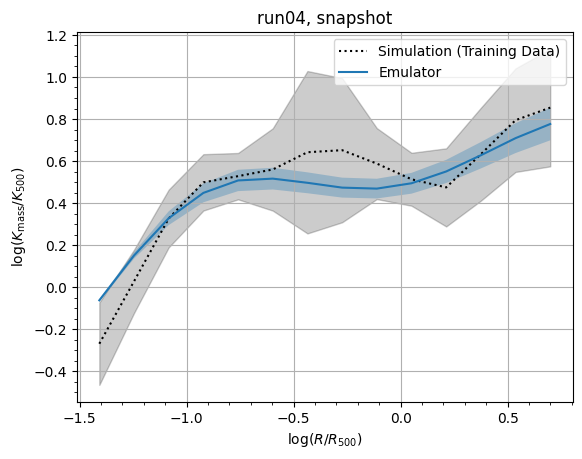

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
pred_y:  [-0.20411795  0.05615572  0.26054021  0.3899911   0.44689212  0.45067143
  0.42871408  0.40695564  0.40373316  0.42801937  0.48076388  0.55710197
  0.6479065   0.74064323  0.82050504]
pred_yerr:  [0.02041179 0.00561557 0.02605402 0.03899911 0.04468921 0.04506714
 0.04287141 0.04069556 0.04037332 0.04280194 0.04807639 0.0557102
 0.06479065 0.07406432 0.0820505 ]


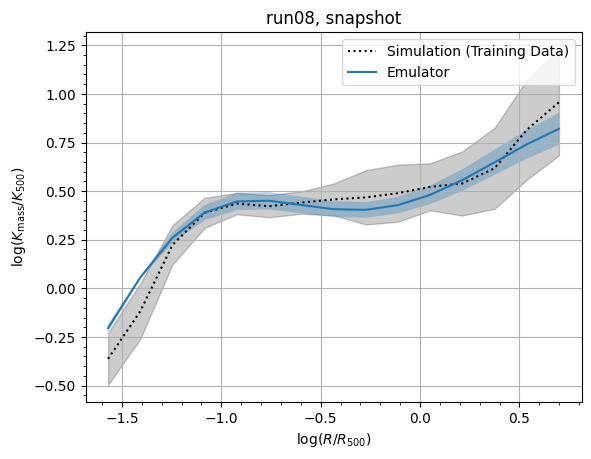

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
pred_y:  [-0.33893754 -0.06561971  0.15566421  0.30211517  0.37298838  0.38626677
  0.36987769  0.35164553  0.35185217  0.38019947  0.43658778  0.51379635
  0.60030802  0.68257359  0.74696348]
pred_yerr:  [0.03389375 0.00656197 0.01556642 0.03021152 0.03729884 0.03862668
 0.03698777 0.03516455 0.03518522 0.03801995 0.04365878 0.05137964
 0.0600308  0.06825736 0.07469635]


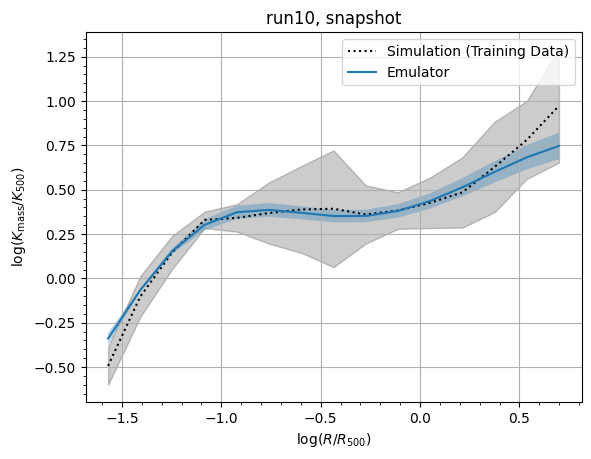

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
pred_y:  [-0.57819076 -0.42974972 -0.28932526 -0.17935378 -0.10970573 -0.07507193
 -0.05772881 -0.03443209  0.01533841  0.10276603  0.22668019  0.3745208
  0.52631919  0.66006478  0.75685418]
pred_yerr:  [0.05781908 0.04297497 0.02893253 0.01793538 0.01097057 0.00750719
 0.00577288 0.00344321 0.00153384 0.0102766  0.02266802 0.03745208
 0.05263192 0.06600648 0.07568542]


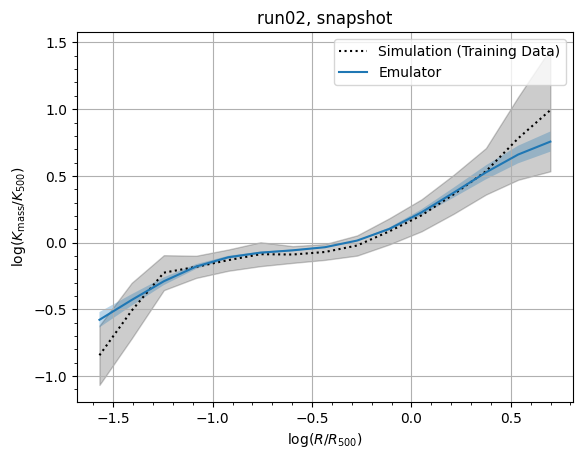

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
pred_y:  [-0.6756869  -0.62447846 -0.57342393 -0.52837009 -0.48657706 -0.43762874
 -0.36759484 -0.26472993 -0.12442793  0.0483537   0.23979536  0.43041969
  0.5994775   0.72915808  0.80768063]
pred_yerr:  [0.06756869 0.06244785 0.05734239 0.05283701 0.04865771 0.04376287
 0.03675948 0.02647299 0.01244279 0.00483537 0.02397954 0.04304197
 0.05994775 0.07291581 0.08076806]


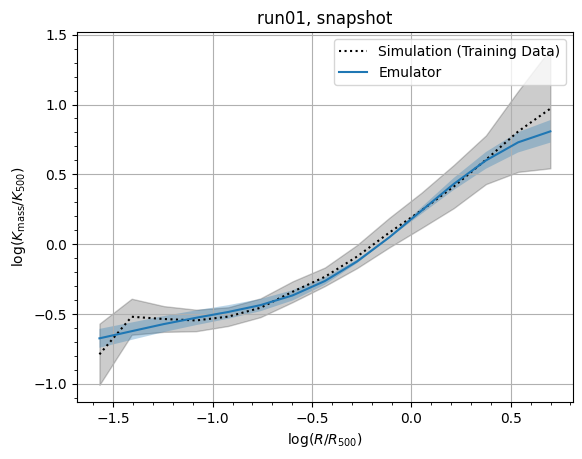

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
pred_y:  [-0.25894126 -0.0825693   0.08594112  0.22396349  0.318667    0.36959294
  0.38733627  0.38924178  0.39389057  0.41612071  0.46367775  0.53585359
  0.62401548  0.7137535   0.78825354]
pred_yerr:  [0.02589413 0.00825693 0.00859411 0.02239635 0.0318667  0.03695929
 0.03873363 0.03892418 0.03938906 0.04161207 0.04636777 0.05358536
 0.06240155 0.07137535 0.07882535]


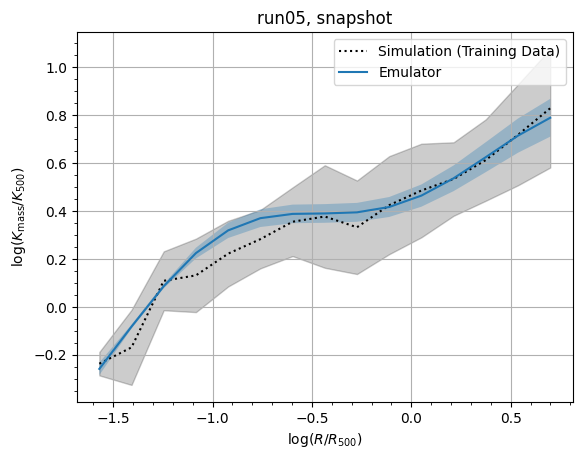

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
pred_y:  [-0.22891615  0.05957773  0.28678544  0.43096794  0.4940443   0.49704042
  0.47016209  0.4422395   0.43357946  0.45371285  0.50288221  0.57488693
  0.65943851  0.74363837  0.81332502]
pred_yerr:  [0.02289161 0.00595777 0.02867854 0.04309679 0.04940443 0.04970404
 0.04701621 0.04422395 0.04335795 0.04537128 0.05028822 0.05748869
 0.06594385 0.07436384 0.0813325 ]


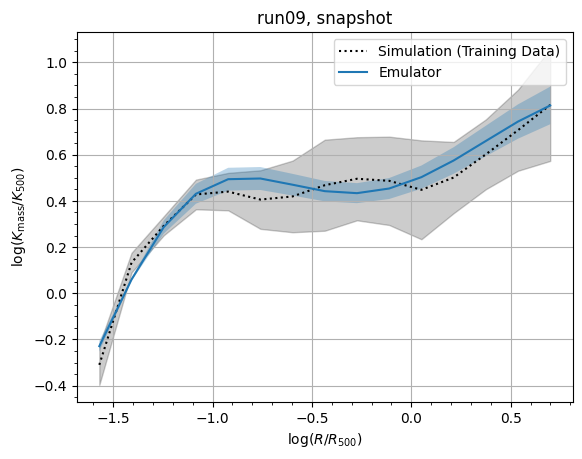

x:  [-1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103 -0.59729758
 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966  0.37490311
  0.53693656  0.69897   ]
pred_y:  [-0.17932574  0.03130764  0.20106851  0.30985086  0.3556474   0.3537122
  0.33031773  0.31370444  0.32551976  0.37535676  0.45949622  0.56343371
  0.6668026   0.74901632]
pred_yerr:  [0.01793257 0.00313076 0.02010685 0.03098509 0.03556474 0.03537122
 0.03303177 0.03137044 0.03255198 0.03753568 0.04594962 0.05634337
 0.06668026 0.07490163]


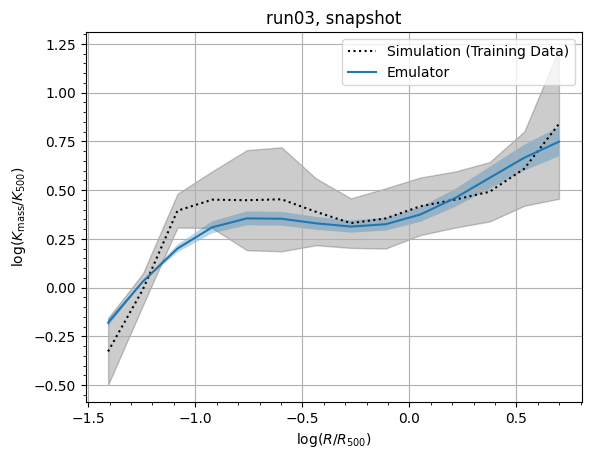

x:  [-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]
pred_y:  [-0.2383708  -0.03481121  0.12868616  0.23613283  0.28829425  0.29974567
  0.29206762  0.28650489  0.29886838  0.33762246  0.40428772  0.49459093
  0.59937767  0.70542385  0.79694964]
pred_yerr:  [0.02383708 0.00348112 0.01286862 0.02361328 0.02882943 0.02997457
 0.02920676 0.02865049 0.02988684 0.03376225 0.04042877 0.04945909
 0.05993777 0.07054239 0.07969496]


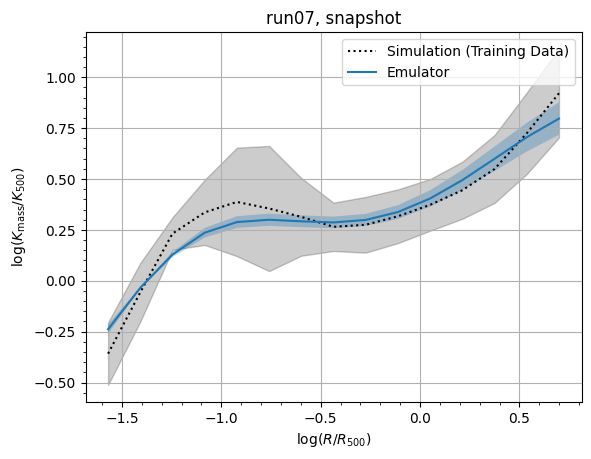

In [29]:
# Make predictions with trained emulator (but now with emulator uncertainties!) to compare to input

for cali in emulator.model_parameters.model_parameters:
    pred_params = emulator.model_parameters[cali]
    pred_x = emulator.model_values[cali]['independent']
    sim_y = emulator.model_values[cali]['dependent']
    sim_yerr = emulator.model_values[cali]['dependent_error']
    
    pred_y, pred_err = emulator_model(pred_x, pred_params, emulator)

    print("x: ", pred_x)
    print("pred_y: ", pred_y)
    print("pred_yerr: ", pred_err) 

    plt.clf()
    plt.xlabel(sim_info['X_LABEL'])
    plt.ylabel(sim_info['Y_LABEL'])
    plt.title(r'%s, %s' % (cali, snap_prefix))
    plt.grid()
    plt.minorticks_on()
    
#     plt.errorbar(pred_x, sim_y, yerr=sim_yerr, color="black", ls=":", label="Simulation (Training Data)")
    plt.errorbar(pred_x, sim_y, color="black", ls=":", label="Simulation (Training Data)")
#     plt.scatter(pred_x, sim_y, color="black", label="Simulation (Training Data)")
    plt.fill_between(pred_x, sim_y-sim_yerr, sim_y+sim_yerr, color='black', alpha=0.2)

#     plt.errorbar(pred_x, pred_y, yerr=pred_err, ls='-', fmt='o', label='Emulator')
    plt.errorbar(pred_x, pred_y, yerr=None, ls='-', label='Emulator')
#     plt.scatter(pred_x, pred_y, label='Emulator')
    plt.fill_between(pred_x, pred_y-pred_err, pred_y+pred_err, alpha=0.3)
    plt.legend()
    plt.show()

## Sweeps of parameter space

In [30]:
# Get full range of x values that have been used in training emulator

#another way of checking parameter sensitivity

sim_x = []
for cali in emulator.model_values.model_values:
    sim_x_curr = emulator.model_values[cali]['independent']
    for x_val in sim_x_curr:
        if x_val not in sim_x:
            sim_x.append(x_val)
            
sim_x = np.array(np.sort(sim_x))
print(sim_x)

[-1.56949827 -1.40746483 -1.24543138 -1.08339793 -0.92136448 -0.75933103
 -0.59729758 -0.43526413 -0.27323069 -0.11119724  0.05083621  0.21286966
  0.37490311  0.53693656  0.69897   ]


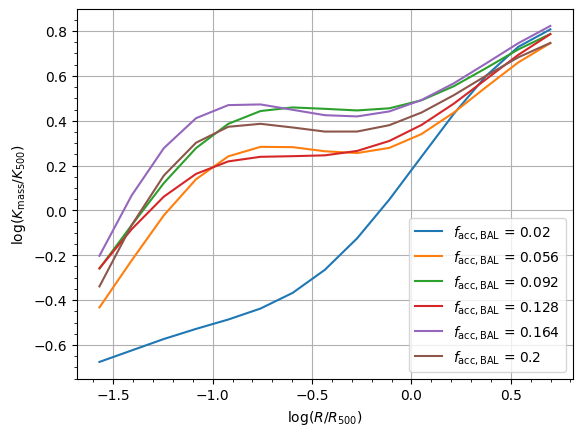

In [32]:
# Arbitrarily choose initial parameters to sweep from
# Doesn't matter too much though, because it ends up covering
# roughly the entire range of parameters used

centre = emulator.model_parameters['run01']

for ii in range(len(emulator.parameter_order)):
    param_name = emulator.parameter_order[ii]
    param_printable_name = emulator.model_specification.parameter_printable_names[ii]
    
    Mock_values, Mock_parameters = mock_sweep(emulator, emulator.model_specification, 6, param_name, centre)

    plt.clf()
    
    for mock_name in Mock_values.keys():
        plt.plot(Mock_values[mock_name]["independent"],
                Mock_values[mock_name]["dependent"],
                label = "%s = %.4g" % (param_printable_name, Mock_parameters[mock_name][param_name]))
#         plt.scatter(Mock_values[mock_name]["independent"],
#                 Mock_values[mock_name]["dependent"],
#                 label = "%s = %.4g" % (param_printable_name, Mock_parameters[mock_name][param_name]))
    
    plt.xlabel(sim_info['X_LABEL'])
    plt.ylabel(sim_info['Y_LABEL'])
    plt.grid()
    plt.minorticks_on()
    plt.legend()
    plt.show()

## Checking hyperparameters (doesn't always work)

In [33]:
emulator.kernel.get_parameter_dict(include_frozen=True)

OrderedDict([('k1:log_constant', -0.6931471805599453),
             ('k2:metric:log_M_0_0', 0.0),
             ('k2:metric:log_M_1_1', 0.0)])

In [34]:
emulator_mcmc = gaussian_process_mcmc.GaussianProcessEmulatorMCMC(burn_in_steps=1, mcmc_steps=1000)#, hide_progress=False)
emulator_mcmc.fit_model(model_specification=model_specification,
                        model_parameters=model_parameters,
                        model_values=model_values)

In [35]:
emulator_mcmc.kernel.get_parameter_dict(include_frozen=True)

OrderedDict([('k1:log_constant', -0.6931471805599453),
             ('k2:metric:log_M_0_0', 0.0),
             ('k2:metric:log_M_1_1', 0.0)])

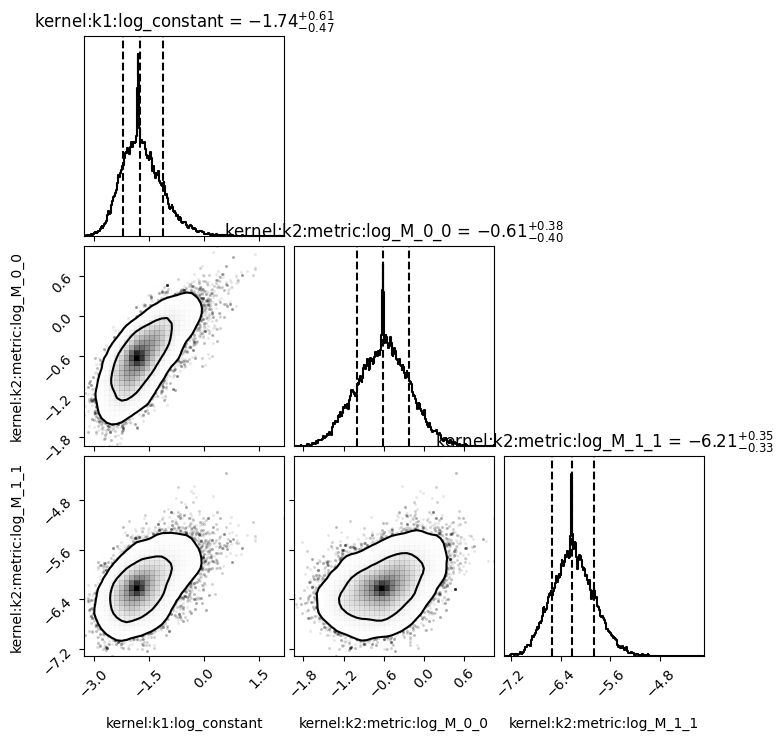

In [36]:
emulator_mcmc.plot_hyperparameter_distribution()

## Save emulator to pickle file with dill module

In [37]:
def save_object(obj, filename):
    with open(filename, 'wb') as f:  # Overwrites any existing file.
        dill.dump(obj, f, dill.HIGHEST_PROTOCOL)

In [38]:
emulator_filename = 'emulator_'+obs_name+'.pkl'
emulator_path = os.path.join(root_dir, 'emulators')
if not os.path.isdir(emulator_path):
    os.makedirs(emulator_path, mode = 0o755, exist_ok=True)
save_object(emulator, os.path.join(emulator_path, emulator_filename))